## Data Loading and EDA in Databricks from Volume

In [0]:
# Define the Volume path
file_path = "/Volumes/dbacademy/ops/labuser15221439_1787894081@vocareum_com/student_performance_dataset.csv"

# Load the dataset using PySpark
df = spark.read.csv(file_path, header=True, inferSchema=True)

# Use Databricks' built-in display function to view the data
display(df)

student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
4,Male,2.6,77.5,8.0,None,Yes,Yes,No,85.1,83.8,B
5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D
6,Female,4.2,78.2,5.7,High School,Yes,No,No,79.8,81.6,B
7,Male,1.5,100.0,5.0,High School,Yes,Yes,Yes,58.6,69.6,D
8,Male,6.2,86.4,6.0,High School,Yes,Yes,No,78.4,88.0,B
9,Male,5.3,81.3,6.7,Bachelors,Yes,No,No,63.8,84.4,B
10,Female,2.8,86.8,5.1,Bachelors,Yes,Yes,No,57.7,74.3,C


Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

## creating feature store -- 

In [0]:
%pip install databricks-feature-engineering
dbutils.library.restartPython()

Looking in indexes: [REDACTED]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 43.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.4
    Not uninstalling protobuf at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-315e4585-ee75-495a-88ca-662c3208e20c
    Can't uninstall 'protobuf'. No files were found to uninstall.
  Attempting uninstall: databricks-sdk
    Found existing installation: databricks-sdk 0.67.0
    Not uninstalling databricks-sdk at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-315e4585-ee75-495a-88ca-662c3208e20c
    Can't uninstall 'databricks-sdk'. No files were found to uninstall.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
from databricks.feature_engineering import FeatureEngineeringClient
from pyspark.sql.functions import col

# Initialize the Feature Engineering Client
fe = FeatureEngineeringClient()

# Define Unity Catalog table location
catalog = "dbacademy"
schema = "labuser15221439_1787894081"
feature_table_name = f"{catalog}.{schema}.student_features"

# 1. Prepare features DataFrame
feature_df = df.select(
    col("student_id").cast("string").alias("student_id"),
    col("gender").cast("string"),
    col("parental_education").cast("string"),
    col("internet_access").cast("string"),
    col("extracurricular_activities").cast("string"),
    col("part_time_job").cast("string"),
    col("study_time_hours").cast("double"),
    col("attendance_percent").cast("double"),
    col("sleep_hours").cast("double"),
    col("previous_grade").cast("double"),
    col("final_exam_score").cast("double"),
    col("final_grade").cast("string")
)

# 2. Create the Unity Catalog Feature Table
fe.create_table(
    name=feature_table_name,
    primary_keys=["student_id"],
    df=feature_df,
    description="Raw and domain features for student performance classification."
)

print(f"Successfully created Feature Table: {feature_table_name}")

2026/08/28 07:51:03 INFO databricks.ml_features._compute_client._compute_client: Setting columns ['student_id'] of table 'dbacademy.labuser15221439_1787894081.student_features' to NOT NULL.
2026/08/28 07:51:04 INFO databricks.ml_features._compute_client._compute_client: Setting Primary Keys constraint ['student_id'] on table 'dbacademy.labuser15221439_1787894081.student_features'.
2026/08/28 07:51:09 INFO databricks.ml_features._compute_client._compute_client: Created feature table 'dbacademy.labuser15221439_1787894081.student_features'.


Successfully created Feature Table: dbacademy.labuser15221439_1787894081.student_features


In [0]:
## checking None values which is here string only 
from pyspark.sql.functions import col, sum, when, trim, lower, isnan

def is_missing(c_name, c_type):
    # 1. Check for standard Nulls (works for all data types)
    condition = col(c_name).isNull()
    
    # 2. Check for np.nan (ONLY if the column is a float or double)
    if c_type in ['double', 'float']:
        condition = condition | isnan(col(c_name))
        
    # 3. Check for string placeholders
    safe_str_col = lower(trim(col(c_name).cast("string")))
    condition = condition | safe_str_col.isin("none", "null", "nan", "")
    
    return condition

# df.dtypes gives us a list of (column_name, data_type) pairs
null_counts = df.select([
    sum(when(is_missing(name, dtype), 1).otherwise(0)).alias(name) 
    for name, dtype in df.dtypes
])

print("Comprehensive missing values count (Nulls, NaNs, and Strings):")
display(null_counts)

Comprehensive missing values count (Nulls, NaNs, and Strings):


student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,0,0,0,0,102,0,0,0,0,0,0


In [0]:
# check df summary with display for EDA 
display(df.summary())

summary,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
mean,500.5,null,3.5707000000000018,85.09229999999984,6.799499999999995,null,null,null,null,69.74089999999998,83.5435000000001,null
stddev,288.8194360957494,null,1.4785593148898841,9.270684780872786,1.2035274106675902,null,null,null,null,12.613425216240257,10.341332646758389,null
min,1,Female,0.5,54.8,3.2,Bachelors,No,No,No,31.3,46.8,A
25%,250,null,2.6,78.8,5.9,null,null,null,null,61.0,76.0,null
50%,500,null,3.6,85.2,6.8,null,null,null,null,69.6,83.8,null
75%,750,null,4.5,91.9,7.6,null,null,null,null,78.4,91.5,null
max,1000,Male,8.1,100.0,10.0,PhD,Yes,Yes,Yes,100.0,100.0,F


/home/spark-315e4585-ee75-495a-88ca-66/.ipykernel/75/command-4686554680314245-3101918248:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=pdf, x='final_grade', order=['A', 'B', 'C', 'D', 'F'], palette='viridis')
/home/spark-315e4585-ee75-495a-88ca-66/.ipykernel/75/command-4686554680314245-3101918248:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pdf, x='final_grade', y='attendance_percent', order=['A', 'B', 'C', 'D', 'F'], palette='viridis')


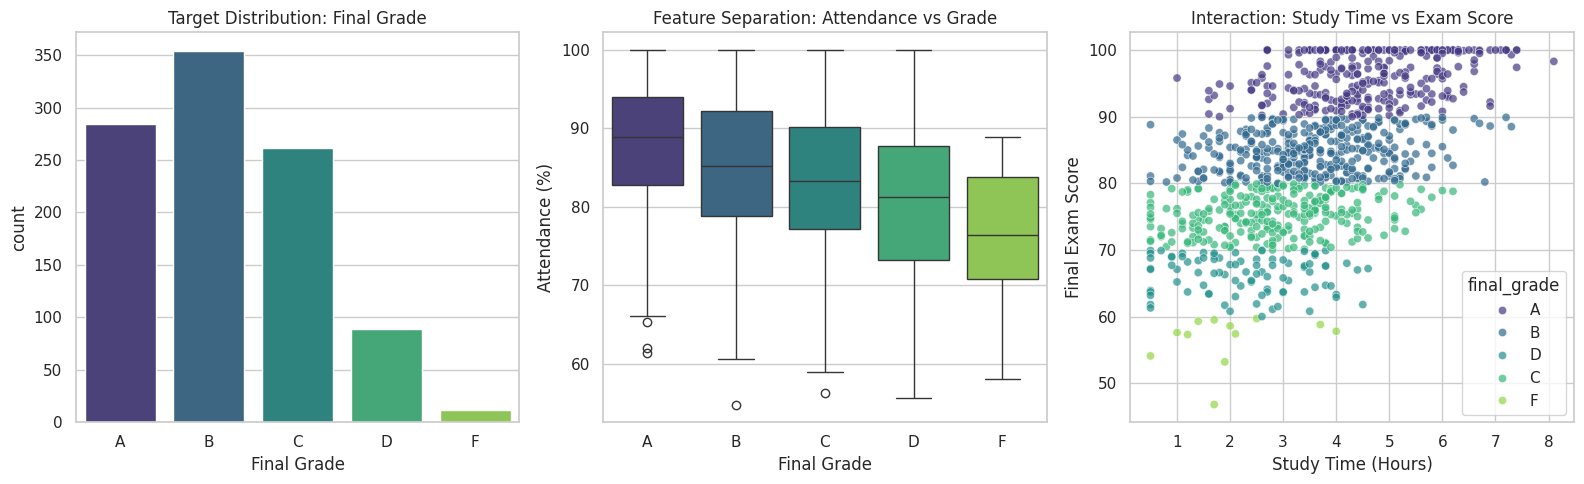

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert PySpark DataFrame to Pandas for plotting
pdf = df.toPandas()

# Set up the figure layout
plt.figure(figsize=(16, 5))
sns.set_theme(style="whitegrid")

# 1. Target Variable Distribution
plt.subplot(1, 3, 1)
sns.countplot(data=pdf, x='final_grade', order=['A', 'B', 'C', 'D', 'F'], palette='viridis')
plt.title('Target Distribution: Final Grade')
plt.xlabel('Final Grade')

# 2. Feature vs Target (Boxplot)
plt.subplot(1, 3, 2)
sns.boxplot(data=pdf, x='final_grade', y='attendance_percent', order=['A', 'B', 'C', 'D', 'F'], palette='viridis')
plt.title('Feature Separation: Attendance vs Grade')
plt.xlabel('Final Grade')
plt.ylabel('Attendance (%)')

# 3. Feature Interaction (Scatter)
plt.subplot(1, 3, 3)
sns.scatterplot(data=pdf, x='study_time_hours', y='final_exam_score', hue='final_grade', palette='viridis', alpha=0.7)
plt.title('Interaction: Study Time vs Exam Score')
plt.xlabel('Study Time (Hours)')
plt.ylabel('Final Exam Score')

plt.tight_layout()
plt.show()

### data preprocessing 

In [0]:
## checking parentail_education column values and their counts
display(df.groupBy("parental_education").count().orderBy("count", ascending=False))


parental_education,count
High School,356
Bachelors,308
Masters,184
None,102
PhD,50


In [0]:
# since missing values are string so we can't use pyspark imputer function here 
from pyspark.sql.functions import col, when, trim, lower

# 1. Find the most frequent value (mode) ignoring missing/None values
mode_row = df.filter(
    col("parental_education").isNotNull() & 
    ~lower(trim(col("parental_education").cast("string"))).isin("none", "null", "nan", "")
).groupBy("parental_education").count().orderBy(col("count").desc()).first()

mode_value = mode_row["parental_education"]
print(f"The most frequent value (mode) to be imputed is: {mode_value}\n")

# 2. Impute the missing values with the mode
df = df.withColumn(
    "parental_education",
    when(
        col("parental_education").isNull() | 
        lower(trim(col("parental_education").cast("string"))).isin("none", "null", "nan", ""), 
        mode_value
    ).otherwise(col("parental_education"))
)

# 3. Verify the changes by counting again
display(df.groupBy("parental_education").count().orderBy(col("count").desc()))

The most frequent value (mode) to be imputed is: High School



parental_education,count
High School,458
Bachelors,308
Masters,184
PhD,50


In [0]:
# chekcing missing values again 
## checking None values which is here string only 
from pyspark.sql.functions import col, sum, when, trim, lower, isnan

def is_missing(c_name, c_type):
    # 1. Check for standard Nulls (works for all data types)
    condition = col(c_name).isNull()
    
    # 2. Check for np.nan (ONLY if the column is a float or double)
    if c_type in ['double', 'float']:
        condition = condition | isnan(col(c_name))
        
    # 3. Check for string placeholders
    safe_str_col = lower(trim(col(c_name).cast("string")))
    condition = condition | safe_str_col.isin("none", "null", "nan", "")
    
    return condition

# df.dtypes gives us a list of (column_name, data_type) pairs
null_counts = df.select([
    sum(when(is_missing(name, dtype), 1).otherwise(0)).alias(name) 
    for name, dtype in df.dtypes
])

print("Comprehensive missing values count (Nulls, NaNs, and Strings):")
display(null_counts)

Comprehensive missing values count (Nulls, NaNs, and Strings):


student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,0,0,0,0,0,0,0,0,0,0,0


# storing into feature table 

In [0]:
from databricks.feature_engineering import FeatureEngineeringClient
from pyspark.sql.functions import col

fe = FeatureEngineeringClient()

catalog = "dbacademy"
schema = "labuser15221439_1787894081"
feature_table_name = f"{catalog}.{schema}.student_features_updated"

# 1. Select ONLY predictor features (Exclude target: final_grade)
feature_df = df.select(
    col("student_id").cast("string").alias("student_id"),
    col("gender").cast("string"),
    col("parental_education").cast("string"),
    col("internet_access").cast("string"),
    col("extracurricular_activities").cast("string"),
    col("part_time_job").cast("string"),
    col("study_time_hours").cast("double"),
    col("attendance_percent").cast("double"),
    col("sleep_hours").cast("double"),
    col("previous_grade").cast("double"),
    col("final_exam_score").cast("double")
)

# 2. Register Unity Catalog Feature Table
fe.create_table(
    name=feature_table_name,
    primary_keys=["student_id"],
    df=feature_df,
    description="Cleaned domain features (predictors only) for student performance."
)

print(f"Successfully created Feature Table (predictors only): {feature_table_name}")

2026/08/28 07:59:02 INFO databricks.ml_features._compute_client._compute_client: Setting columns ['student_id'] of table 'dbacademy.labuser15221439_1787894081.student_features_updated' to NOT NULL.
2026/08/28 07:59:03 INFO databricks.ml_features._compute_client._compute_client: Setting Primary Keys constraint ['student_id'] on table 'dbacademy.labuser15221439_1787894081.student_features_updated'.
2026/08/28 07:59:08 INFO databricks.ml_features._compute_client._compute_client: Created feature table 'dbacademy.labuser15221439_1787894081.student_features_updated'.


Successfully created Feature Table (predictors only): dbacademy.labuser15221439_1787894081.student_features_updated


In [0]:
# creating a label table also 
label_table_name = f"{catalog}.{schema}.student_labels"

# Select student_id and final_grade
labels_df = df.select(
    col("student_id").cast("string").alias("student_id"),
    col("final_grade").cast("string")
)

# Save as Delta Table
labels_df.write.format("delta").mode("overwrite").saveAsTable(label_table_name)

print(f"Successfully created Ground Truth Label Table: {label_table_name}")

Successfully created Ground Truth Label Table: dbacademy.labuser15221439_1787894081.student_labels


In [0]:
# removing unwanted col -- student_id
# Drop the unwanted student_id column
df = df.drop("student_id")

# Verify it is gone
print("Columns remaining:", df.columns)

Columns remaining: ['gender', 'study_time_hours', 'attendance_percent', 'sleep_hours', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job', 'previous_grade', 'final_exam_score', 'final_grade']


In [0]:
# keeping features and label seperately 
# Define the target variable
target_col = "final_grade"

# Define the feature variables (all columns except the target)
feature_cols = [col for col in df.columns if col != target_col]

print("Feature Columns:", feature_cols)
print("Target Column:", target_col)

Feature Columns: ['gender', 'study_time_hours', 'attendance_percent', 'sleep_hours', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job', 'previous_grade', 'final_exam_score']
Target Column: final_grade


### Implementing  Encoding like stringIndexer , OHE , vectorassember using feature table 

In [0]:
from databricks.feature_engineering import FeatureEngineeringClient, FeatureLookup
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, RobustScaler
from pyspark.ml import Pipeline

# 1. Initialize Feature Engineering Client
fe = FeatureEngineeringClient()

catalog = "dbacademy"
schema = "labuser15221439_1787894081"
feature_table_name = f"{catalog}.{schema}.student_features_updated"
label_table_name = f"{catalog}.{schema}.student_labels"

# 2. Load Ground Truth Observation DataFrame (Target + Primary Key)
observation_df = spark.table(label_table_name)

# 3. Define Feature Lookups to retrieve predictors from Feature Store
feature_cols = [
    "gender", "parental_education", "internet_access", 
    "extracurricular_activities", "part_time_job", 
    "study_time_hours", "attendance_percent", 
    "sleep_hours", "previous_grade", "final_exam_score"
]

feature_lookups = [
    FeatureLookup(
        table_name=feature_table_name,
        feature_names=feature_cols,
        lookup_key="student_id"
    )
]

# 4. Create Training Set via Feature Store Client
training_set = fe.create_training_set(
    df=observation_df,
    feature_lookups=feature_lookups,
    label="final_grade",
    exclude_columns=["student_id"]
)

# 5. Load combined dataset
dataset_df = training_set.load_df()

# 6. Split raw dataset FIRST (Prevents Data Leakage)
train_df, test_df = dataset_df.randomSplit([0.8, 0.2], seed=42)

# 7. Define Feature Groups
categorical_features = ["gender", "parental_education", "internet_access", "extracurricular_activities", "part_time_job"]
numeric_features = ["study_time_hours", "attendance_percent", "sleep_hours", "previous_grade", "final_exam_score"]

# 8. Define Preprocessing Stages
indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_index", handleInvalid="keep") for c in categorical_features]
encoders = [OneHotEncoder(inputCol=f"{c}_index", outputCol=f"{c}_ohe") for c in categorical_features]
label_indexer = StringIndexer(inputCol="final_grade", outputCol="label", handleInvalid="keep")

# 9. Numeric Vector Assembly & Robust Scaling
numeric_assembler = VectorAssembler(inputCols=numeric_features, outputCol="numeric_vector")
robust_scaler = RobustScaler(
    inputCol="numeric_vector", 
    outputCol="scaled_numeric_vector", 
    withScaling=True, 
    withCentering=True
)

# 10. Combine Categorical OHE + Scaled Numeric Vectors
final_assembler_inputs = [f"{c}_ohe" for c in categorical_features] + ["scaled_numeric_vector"]
final_assembler = VectorAssembler(inputCols=final_assembler_inputs, outputCol="features")

# 11. Bundle all stages into a Master Pipeline
pipeline = Pipeline(stages=indexers + encoders + [label_indexer, numeric_assembler, robust_scaler, final_assembler])

# 12. Fit Pipeline ONLY on training data (Learns IQR/median from train set strictly)
pipeline_model = pipeline.fit(train_df)

# 13. Transform both train and test sets
train_processed = pipeline_model.transform(train_df)
test_processed = pipeline_model.transform(test_df)

# Display processed training feature vector
display(train_processed.select("features", "label", "final_grade"))

features,label,final_grade
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0"",""0.0"",""0.0"",""1.0"",""0.0"",""0.0"",""0.0"",""1.0"",""0.0"",""1.0"",""1.0"",""0.0"",""-0.2631578947368421"",""-1.2213740458015272"",""-1.1764705882352946"",""0.49717514124293843"",""-0.6923076923076924""]}",2.0,C
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0"",""0.0"",""0.0"",""1.0"",""0.0"",""0.0"",""0.0"",""1.0"",""0.0"",""1.0"",""1.0"",""0.0"",""-0.21052631578947362"",""-0.7786259541984738"",""0.6470588235294118"",""0.3220338983050849"",""-0.1602564102564103""]}",0.0,B
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0"",""0.0"",""0.0"",""1.0"",""0.0"",""0.0"",""0.0"",""1.0"",""0.0"",""1.0"",""1.0"",""0.0"",""0.5263157894736842"",""-0.6412213740458023"",""-1.058823529411765"",""0.5254237288135599"",""-0.27564102564102555""]}",2.0,C
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0"",""0.0"",""0.0"",""1.0"",""0.0"",""0.0"",""0.0"",""1.0"",""0.0"",""1.0"",""1.0"",""0.0"",""1.3157894736842104"",""-1.1832061068702295"",""0.05882352941176452"",""-0.24293785310734445"",""0.3782051282051287""]}",0.0,B
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0"",""0.0"",""0.0"",""1.0"",""0.0"",""0.0"",""0.0"",""1.0"",""0.0"",""1.0"",""1.0"",""0.0"",""1.6842105263157894"",""-0.20610687022900792"",""0.5882352941176473"",""-0.3559322033898303"",""0.34615384615384664""]}",0.0,B
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0"",""0.0"",""0.0"",""1.0"",""0.0"",""0.0"",""0.0"",""1.0"",""0.0"",""1.0"",""0.0"",""1.0"",""-0.42105263157894723"",""0.41984732824427495"",""0.5294117647058822"",""-1.1751412429378527"",""-0.6474358974358972""]}",2.0,C
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0"",""0.0"",""0.0"",""1.0"",""0.0"",""0.0"",""0.0"",""1.0"",""1.0"",""0.0"",""1.0"",""0.0"",""-1.1052631578947367"",""-0.25190839694656475"",""0.7058823529411768"",""-0.3163841807909601"",""-0.7692307692307695""]}",2.0,C
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0"",""0.0"",""0.0"",""1.0"",""0.0"",""0.0"",""0.0"",""1.0"",""1.0"",""0.0"",""1.0"",""0.0"",""-0.9473684210526315"",""0.22137404580152614"",""0.47058823529411775"",""0.1299435028248594"",""-0.8205128205128206""]}",2.0,C
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0"",""0.0"",""0.0"",""1.0"",""0.0"",""0.0"",""0.0"",""1.0"",""1.0"",""0.0"",""1.0"",""0.0"",""-0.36842105263157904"",""0.37404580152671707"",""-0.5294117647058828"",""0.8192090395480225"",""0.38461538461538475""]}",0.0,B
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0"",""0.0"",""0.0"",""1.0"",""0.0"",""0.0"",""0.0"",""1.0"",""1.0"",""0.0"",""1.0"",""0.0"",""-0.05263157894736847"",""1.1297709923664125"",""0.05882352941176452"",""-1.4067796610169485"",""-0.39743589743589686""]}",2.0,C


## model training using MLflow



In [0]:
import mlflow
import mlflow.spark
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Point to your active volume directory for temporary serialization
volume_tmp_path = "/Volumes/dbacademy/ops/labuser15221439_1787894081@vocareum_com/mlflow_tmp"

# 1. Start MLflow Run
with mlflow.start_run(run_name="student_perf_rf_feature_store") as run:
    
    # 2. Define Classifier
    rf = RandomForestClassifier(
        featuresCol="features", 
        labelCol="label", 
        numTrees=100, 
        maxDepth=5, 
        seed=42
    )
    
    # 3. Combine Preprocessing Stages + Classifier into Master Pipeline
    full_stages = indexers + encoders + [label_indexer, numeric_assembler, robust_scaler, final_assembler, rf]
    full_pipeline = Pipeline(stages=full_stages)
    
    # 4. Fit Pipeline strictly on training data
    print("Training Random Forest model via Feature Store pipeline...")
    fitted_model = full_pipeline.fit(train_df)
    
    # 5. Make predictions on unseen test set
    predictions = fitted_model.transform(test_df)
    
    # 6. Evaluate Accuracy and F1 Score
    evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
    evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
    
    accuracy = evaluator_acc.evaluate(predictions)
    f1_score = evaluator_f1.evaluate(predictions)
    
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test F1 Score:  {f1_score:.4f}")
    
    # 7. Log Parameters & Metrics to MLflow
    mlflow.log_param("numTrees", 100)
    mlflow.log_param("maxDepth", 5)
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("f1_score", f1_score)
    
    # 8. Log Model via Feature Engineering Client using your Volume path
    fe.log_model(
        model=fitted_model,
        artifact_path="random_forest_model",
        flavor=mlflow.spark,
        training_set=training_set,
        dfs_tmpdir=volume_tmp_path
    )
    
    run_id = run.info.run_id
    print(f"Successfully logged model! Run ID: {run_id}")

# Display sample predictions
display(predictions.select("features", "label", "prediction", "probability"))

Training Random Forest model via Feature Store pipeline...
Test Accuracy: 0.9095
Test F1 Score:  0.8903


2026/08/28 09:00:51 WARNING mlflow.utils.requirements_utils: Found pyspark version (4.1.0+databricks.connect.18.0.9) contains a local version label (+databricks.connect.18.0.9). MLflow logged a pip requirement for this package as 'pyspark==4.1.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/08/28 09:01:06 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /local_disk0/user_tmp_data/spark-315e4585-ee75-495a-88ca-66/tmpwxyucsho/feature_store/raw_model, flavor: spark). Fall back to return ['pyspark==4.1.0']. Set logging level to DEBUG to see the full traceback. 
🔗 View Logged Model at: https://dbc-2c1d2563-9d9d.cloud.databricks.com/ml/experiments/723994123536771/models/m-114f136d141f4bf6b33f62b0dd0aa570?o=7474658371722322
/databricks/python/lib/python3.12/site-packages/mlflow/pyfunc/__init__.py:3285

Successfully logged model! Run ID: 3ef05c74f5bf48ccab0ca89823180405


features,label,prediction,probability
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0"",""0.0"",""0.0"",""1.0"",""0.0"",""0.0"",""0.0"",""1.0"",""1.0"",""0.0"",""1.0"",""0.0"",""-0.4736842105263157"",""-0.2671755725190841"",""0.35294117647058815"",""0.7401129943502829"",""-0.8782051282051277""]}",3.0,2.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.13517255796911828"",""0.023093653163710412"",""0.688999685882563"",""0.13038210681020862"",""0.022351996174399764"",""0.0""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0"",""0.0"",""0.0"",""1.0"",""0.0"",""0.0"",""0.0"",""1.0"",""1.0"",""0.0"",""1.0"",""0.0"",""0.05263157894736847"",""0.37404580152671707"",""-0.882352941176471"",""1.0225988700564976"",""0.6217948717948721""]}",1.0,1.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.1929261544322177"",""0.7628877449280825"",""0.03338667252605258"",""0.00923954787412617"",""0.0015598802395209582"",""0.0""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0"",""0.0"",""0.0"",""1.0"",""0.0"",""0.0"",""0.0"",""1.0"",""1.0"",""0.0"",""1.0"",""0.0"",""0.8421052631578945"",""-1.4122137404580157"",""-0.058823529411765045"",""-0.7401129943502821"",""-0.544871794871795""]}",2.0,2.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.13640365992128162"",""0.015588210667023226"",""0.7303678441307547"",""0.10763023038595682"",""0.010010054894983756"",""0.0""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0"",""0.0"",""0.0"",""1.0"",""0.0"",""0.0"",""1.0"",""0.0"",""0.0"",""1.0"",""1.0"",""0.0"",""-1.2105263157894735"",""-0.11450381679389318"",""-0.47058823529411775"",""0.7627118644067795"",""-0.2948717948717946""]}",2.0,2.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.13905519650215764"",""0.0266046797679486"",""0.700093912646897"",""0.11037087613694382"",""0.02387533494605294"",""0.0""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0"",""0.0"",""0.0"",""1.0"",""0.0"",""0.0"",""1.0"",""0.0"",""0.0"",""1.0"",""1.0"",""0.0"",""-1.1052631578947367"",""0.4351145038167943"",""0.29411764705882365"",""-0.429378531073446"",""-0.5769230769230771""]}",2.0,2.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.10183027782100987"",""0.018775325877822987"",""0.7202698665158191"",""0.1451797645872109"",""0.013944765198137128"",""0.0""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0"",""0.0"",""0.0"",""1.0"",""0.0"",""0.0"",""1.0"",""0.0"",""0.0"",""1.0"",""1.0"",""0.0"",""-1.0526315789473684"",""0.33587786259541935"",""0.5882352941176473"",""0.22598870056497172"",""-0.09615384615384619""]}",0.0,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.8067481473442384"",""0.0654300826978273"",""0.09962776340320349"",""0.025030696404926157"",""0.003163310149804611"",""0.0""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0"",""0.0"",""0.0"",""1.0"",""0.0"",""0.0"",""1.0"",""0.0"",""0.0"",""1.0"",""1.0"",""0.0"",""-0.7368421052631579"",""-0.2977099236641227"",""1.2941176470588243"",""-1.3672316384180787"",""-0.5641025641025641""]}",2.0,2.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.08574770176496462"",""0.012781608170513223"",""0.7209888040152341"",""0.1714987467968813"",""0.008983139252406663"",""0.0""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0"",""0.0"",""0.0"",""1.0"",""0.0"",""0.0"",""1.0"",""0.0"",""0.0"",""1.0"",""1.0"",""0.0"",""-0.6315789473684211"",""-0.25954198473282497"",""-1.3529411764705888"",""-0.3446327683615816"",""-0.6089743589743591""]}",2.0,2.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.06392491029685178"",""0.006121134097170962"",""0.7535043159232221"",""0.16181753795066933"",""0.014632101732085854"",""0.0""]}"
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""1.0"",""0.0"",""0.0"",""1.0"",""0.0"",""0.0"",""1.0"",""0.0"",""0.0"",""1.0"",""1.

### register model to UC

In [0]:
import mlflow

# 1. Set MLflow registry target to Unity Catalog
mlflow.set_registry_uri("databricks-uc")

# 2. Define full 3-level Unity Catalog model path
catalog = "dbacademy"
schema = "labuser15221439_1787894081"
model_name = f"{catalog}.{schema}.student_performance_rf_model"
model_uri = f"runs:/{run_id}/random_forest_model"

# 3. Register the model artifact
registered_model = mlflow.register_model(
    model_uri=model_uri,
    name=model_name
)

print(f"Successfully registered model to Unity Catalog: {model_name}")
print(f"Model Version: {registered_model.version}")

Successfully registered model 'dbacademy.labuser15221439_1787894081.student_performance_rf_model'.
2026/08/28 09:02:36 WARNING mlflow.tracking._model_registry.fluent: Run with id 3ef05c74f5bf48ccab0ca89823180405 has no artifacts at artifact path 'random_forest_model', registering model based on models:/m-114f136d141f4bf6b33f62b0dd0aa570 instead


Uploading artifacts:   0%|          | 0/134 [00:00<?, ?it/s]

Successfully registered model to Unity Catalog: dbacademy.labuser15221439_1787894081.student_performance_rf_model
Model Version: 1


🔗 Created version '1' of model 'dbacademy.labuser15221439_1787894081.student_performance_rf_model': https://dbc-2c1d2563-9d9d.cloud.databricks.com/explore/data/models/dbacademy/labuser15221439_1787894081/student_performance_rf_model/version/1?o=7474658371722322
